# Snapshot eval catplot — PPO vs SAC vs DreamerV3 on a single eval setting

Compares **per-episode eval metrics** of the GEN snapshots across algorithms on a
**single held-out eval setting** (`EVAL_CFG`). The x-axis carries the **algorithms**
(PPO, SAC, DreamerV3) plus an **RBC group** of rule-based baselines; within each
group's slot its **variants** are drawn as **dodged catplot strips** side by side —
the RL algorithms fan out over the training variants (`so_only_17kW`,
`so_only_15kW`, `so_all`, `capacity_sampled`), the RBC group over the rule-based
strategies. Each slot dodges **only its own variants** (per-group hue sets), so the
nine strategies do not shatter the RL slots. One dot per eval episode, coloured by
variant; each strip carries a **stat glyph** marking **mean**, **mean ± 1 std**,
**median**, **min** and **max**. Each metric — return (`total_reward`),
`cum_E_kWh`, `cum_price_EUR` — gets its own figure.

All eval runs of a snapshot's chosen eval kind are pooled (a snapshot may hold one
default run plus `_seed<N>` fan-outs). Within one source, CSVs that resolve to a
**duplicate seed** are dropped with a note — the same checkpoint evaluated with the
same seed replays the identical episodes. A source whose snapshot has **no eval
results yet** is skipped with a warning (its strip appears once the eval run exists),
so the comparison stays runnable while individual evals are pending.

Two result layouts are supported, selected via `EVAL_CFG`:

| Layout | Result CSVs | `EVAL_CFG` |
|---|---|---|
| STA (single eval config) | `eval_results/*_eval/eval_*.csv` | `None` |
| GEN (held-out configs) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | `"eval_<i>"` |

Eval kinds mirror `snapshot_eval_violins_evalcfg_compare.ipynb`:

| `eval-kind` | Run directory pattern | Producer | Per-run CSV |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `episodes.csv` |

**Main input:** set `SOURCES`, `VARIANT_COLORS` and `EVAL_CFG` in the next cell.


In [21]:

# --- Main input ---------------------------------------------------------------------
# One source per (algorithm, training variant). Algorithms are drawn left to right on
# the x-axis (first-appearance order); the variants are dodged side by side within
# each algorithm's slot (first-appearance order, coloured via VARIANT_COLORS).
# Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* dirs to use
#   algo          x-axis category (also used in the PDF filenames)
#   variant       training-variant label, the dodge/hue group (shared across algos)
#   runs          (optional) restrict to these runs/<name> directories; default: all
#   rbc-strategy  (eval-rbc only) which rule-based strategy to use



SOURCES = [
    # --- SAC -------------------------------------------------------------------
    {
        "path": "snapshots/20260719_171314_gen_lin_bat_pv_all_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "N gen.",
    },
    {
        "path": "snapshots/20260719_171327_gen_lin_bat_pv_spec_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "specific",
    },
    {
        "path": "snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "distribution gen.",
    },
    # --- PPO -------------------------------------------------------------------
    {
        "path": "snapshots/20260719_171650_gen_lin_bat_pv_all_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "N gen.",
    },
    {
        "path": "snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "specific",
    },
    {
        "path": "snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "distribution gen.",
    },
    # --- DreamerV3 (only capacity_sampled was trained; eval run still pending) ---
]

# Rule-based baselines: every strategy of this snapshot's eval_rbc run becomes one
# strip in the "RBC" x-axis group (drop entries here to trim the group). The
# rule-based eval is policy-independent — any snapshot with an eval_rbc run works.
RBC_SNAPSHOT = "snapshots/20260719_171314_gen_lin_bat_pv_all_sac/"
RBC_STRATEGIES = (
    "do_nothing",
    "deficit_discharge",
    # "pv_surplus_charge",
    "self_coverage",
    "price_median",
    "price_median_scaled_0.25",
    # "price_median_scaled_0.5",
    # "price_median_scaled_0.75",
    "price_median_autarky",
)
SOURCES += [
    {"path": RBC_SNAPSHOT, "eval-kind": "eval-rbc", "algo": "RBC",
     "variant": strategy, "rbc-strategy": strategy}
    for strategy in RBC_STRATEGIES
]

# Episode-dot colour per variant, identical across the algorithm groups.
VARIANT_COLORS = {
    # RL training variants
    "N gen.": "#3f83d4",
    "specific": "#d99310",
    "distribution gen.": "#a855d8",
    # RBC strategies (own x-group; the price_median family shares a teal ramp)
    "do_nothing": "#5c6670",
    "deficit_discharge": "#c05746",
    # "pv_surplus_charge": "#bfa229",
    "self_coverage": "#4a5899",
    "price_median": "#0f6a60",
    "price_median_scaled_0.25": "#8ec7c0",
    "price_median_scaled_0.5": "#55a79d",
    "price_median_scaled_0.75": "#2c887d",
    "price_median_autarky": "#c26fa1",
}

# The single eval setting every source is compared on. For GEN snapshots with
# per-config result dirs this selects the held-out config `<name>_eval_<i>`
# (battery_lin_cap: eval_1 = BES 12 kWh, eval_2 = BES 16 kWh, eval_3 = BES 22 kWh).
# None selects the flat STA layout instead (one eval config per trial, CSVs directly
# under eval_results/*_eval/).
EVAL_CFG: str | None = "eval_2"

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")


In [22]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_cap_eval_1);
# training-config directories (e.g. battery_lin_cap_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# `eval_<i>` for a held-out eval-config result dir name, None for anything else.
def _cfg_dir_setting(dir_name: str) -> str | None:
    match = _EVAL_CFG_DIR_PATTERN.search(dir_name)
    return f"eval_{match.group(1)}" if match else None


# Ray/SB3 eval CSVs carry a sidecar JSON (same stem) with the run's trial seed + algorithm.
def _sidecar_seed_and_algorithm(csv_path: Path) -> tuple[int | None, str | None]:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None, None
    try:
        payload = json.loads(sidecar.read_text())
    except (json.JSONDecodeError, OSError):
        return None, None
    return payload.get("seed"), payload.get("algorithm")


# Rule-based runs record resolved_seed in an args.json above episodes.csv (directly
# above the per-strategy dir in the flat layout, one level further up with per-config
# dirs) — walk up towards the run dir and take the first hit.
def _rbc_resolved_seed(csv_path: Path, run_dir: Path) -> int | None:
    for candidate_dir in csv_path.parents:
        args_path = candidate_dir / "args.json"
        if args_path.is_file():
            try:
                return json.loads(args_path.read_text()).get("resolved_seed")
            except (json.JSONDecodeError, OSError):
                return None
        if candidate_dir == run_dir:
            return None
    return None


# Discovers one record per eval CSV of `source` on the selected eval setting. Both
# layouts are globbed; every record is tagged with its setting ("default" for the flat
# STA layout, `eval_<i>` for held-out GEN config dirs) and filtered to the single
# setting EVAL_CFG selects.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if wanted_runs := source.get("runs"):
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.name in set(wanted_runs)]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            # flat: .../<strategy>/episodes.csv — nested: .../<strategy>/<cfg>_eval_<i>/episodes.csv
            candidates = [
                (csv_path, "default", csv_path.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name), csv_path.parent.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            ]
            strategies = sorted({strategy for _, _, strategy in candidates})
            strategy_wanted = source.get("rbc-strategy")
            if strategy_wanted is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['algo']} — {source['variant']}': multiple rule-based strategies "
                    f"{strategies} under {run_dir.name} — set 'rbc-strategy' to pick one."
                )
            for csv_path, setting, strategy in candidates:
                if setting is None or (strategy_wanted is not None and strategy != strategy_wanted):
                    continue
                records.append({
                    "algo": source["algo"], "variant": source["variant"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "setting": setting, "seed": _rbc_resolved_seed(csv_path, run_dir),
                    "eval_algorithm": strategy, "csv": csv_path,
                })
        else:
            candidates = [
                (csv_path, "default")
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name))
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
            ]
            for csv_path, setting in candidates:
                if setting is None:
                    continue  # training-config result dir — not a held-out eval config
                seed, algorithm = _sidecar_seed_and_algorithm(csv_path)
                records.append({
                    "algo": source["algo"], "variant": source["variant"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "setting": setting, "seed": seed,
                    "eval_algorithm": algorithm, "csv": csv_path,
                })

    wanted_setting = EVAL_CFG or "default"
    available = sorted({record["setting"] for record in records})
    records = [record for record in records if record["setting"] == wanted_setting]
    if not records:
        raise FileNotFoundError(
            f"Source '{source['algo']} — {source['variant']}': no eval CSVs on setting '{wanted_setting}' "
            f"under {snapshot_dir} (available: {available or 'none'}) — adjust EVAL_CFG or the source."
        )
    return records


_source_keys = [(source["algo"], source["variant"]) for source in SOURCES]
if len(_source_keys) != len(set(_source_keys)):
    raise ValueError(f"Every source needs a unique (algo, variant) pair; got {_source_keys}")
_missing_colors = sorted({source["variant"] for source in SOURCES} - set(VARIANT_COLORS))
if _missing_colors:
    raise ValueError(f"VARIANT_COLORS lacks an entry for variant(s) {_missing_colors}")

# Pool a source's eval runs, but keep only the first CSV per resolved seed: the same
# checkpoint evaluated with the same seed replays the identical eval episodes, so a
# duplicate seed would double-count them. Seed-less CSVs are kept and flagged. A
# source without eval results (eval run still pending) is skipped with a warning.
eval_records: list[dict] = []
print(f"Repo root   : {REPO_ROOT}")
print(f"Eval setting: {EVAL_CFG or 'default (flat single-config layout)'}")
for source in SOURCES:
    try:
        discovered = sorted(_discover_source_records(source), key=lambda record: (record["run"], record["csv"].name))
    except FileNotFoundError as error:
        print(f"\nWARNING: source '{source['algo']} — {source['variant']}' skipped — {error}")
        continue
    kept, seen_seeds = [], set()
    for record in discovered:
        if record["seed"] is not None and record["seed"] in seen_seeds:
            print(f"note: source '{source['algo']} — {source['variant']}': dropped {record['run']} / "
                  f"{record['csv'].name} (duplicate seed {record['seed']})")
            continue
        if record["seed"] is None:
            print(f"WARNING: source '{source['algo']} — {source['variant']}': no seed resolvable for "
                  f"{record['csv'].name} — kept, duplicate eval runs undetectable")
        else:
            seen_seeds.add(record["seed"])
        kept.append(record)
    eval_records.extend(kept)

    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['algo']} — {source['variant']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in kept:
        print(f"  seed {str(record['seed']):>5}  <-  {record['run']} / {record['csv'].name}  [{record['eval_algorithm']}]")

if not eval_records:
    raise FileNotFoundError("No eval CSVs discovered for any source — nothing to plot.")

# x-axis / hue orders = first-appearance order in SOURCES, restricted to the sources
# that yielded eval results.
_algos_with_records = {record["algo"] for record in eval_records}
_variants_with_records = {record["variant"] for record in eval_records}
algo_labels = list(dict.fromkeys(source["algo"] for source in SOURCES if source["algo"] in _algos_with_records))
variant_labels = list(dict.fromkeys(source["variant"] for source in SOURCES if source["variant"] in _variants_with_records))
variant_palette = {variant: VARIANT_COLORS[variant] for variant in variant_labels}

# Per-algorithm variant lists (in variant_labels order): each algorithm's slot dodges
# only over its OWN variants, so e.g. the RBC strategies do not shatter the RL slots.
algo_variants = {
    algo: [variant for variant in variant_labels
           if any(record["algo"] == algo and record["variant"] == variant for record in eval_records)]
    for algo in algo_labels
}


Repo root   : /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Eval setting: eval_2

Source 'SAC — N gen.' (eval-ray): snapshots/20260719_171314_gen_lin_bat_pv_all_sac
  seed    42  <-  eval_20260721_103503 / eval_checkpoint_000348_20260721_104430.csv  [sac]

Source 'SAC — specific' (eval-ray): snapshots/20260719_171327_gen_lin_bat_pv_spec_sac
  seed    42  <-  eval_20260721_103506 / eval_checkpoint_000348_20260721_104430.csv  [sac]

Source 'SAC — distribution gen.' (eval-ray): snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac
  seed    42  <-  eval_20260721_103508 / eval_checkpoint_000348_20260721_105430.csv  [sac]

Source 'PPO — N gen.' (eval-ray): snapshots/20260719_171650_gen_lin_bat_pv_all_ppo
  seed    42  <-  eval_20260721_103510 / eval_checkpoint_000058_20260721_105430.csv  [ppo]

Source 'PPO — specific' (eval-ray): snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo
  seed    42  <-  eval_20260721_103512 / eval_checkpoint_000058_20260721_110351.csv  [ppo]

Source 'PPO — distribut

## Load per-episode metrics

Every kept CSV is concatenated into one long-format frame, one row per eval episode,
tagged with its `algo`, training `variant` and the eval run's `seed`. A CSV missing a
metric column is simply absent from that metric's figure.


In [23]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['algo']} — {record['variant']}' {record['run']} lacks {missing} — "
              "skipped in those figures")
    frame = csv_frame[present].copy()
    frame["algo"] = record["algo"]
    frame["variant"] = record["variant"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

episodes.groupby(["algo", "variant"]).agg(
    episodes=("seed", "size"),
    eval_seeds=("seed", "nunique"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
).reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")


episodes  eval_seeds  mean_total_reward  \
algo variant                                                             
SAC  N gen.                          10           1          19.387978   
     specific                        10           1          19.864028   
     distribution gen.               10           1          18.545265   
PPO  N gen.                          10           1          18.726408   
     specific                        10           1          18.693778   
     distribution gen.               10           1          19.085956   
RBC  do_nothing                      10           1          11.649384   
     deficit_discharge               10           1           9.075153   
     self_coverage                   10           1           9.011907   
     price_median                    10           1          11.344708   
     price_median_scaled_0.25        10           1          14.385014   
     price_median_autarky            10           1          12.585391   

                               mean_cum_E_kWh  mean_cum_price_EUR  
algo variant                                                       
SAC  N gen.                         76.145481           -4.416631  
     specific                       76.145481           -4.499630  
     distribution gen.              75.125481           -4.024965  
PPO  N gen.                         76.145481           -4.260017  
     specific                       75.125481           -4.016744  
     distribution gen.              76.145481           -4.167817  
RBC  do_nothing                     73.882293           -2.746635  
     deficit_discharge              67.176531           -2.200242  
     self_coverage                  67.054909           -2.190498  
     price_median                   70.415656           -2.705491  
     price_median_scaled_0.25       72.569793           -3.329387  
     price_median_autarky           73.882293           -2.915859

## Catplots with stat glyphs

One categorical strip figure per metric (the axes-level form of
`catplot(kind="strip")` — one `stripplot` layer per algorithm, so each slot dodges
over **its own variants only**: the RL slots split into the training variants, the
RBC slot into the rule-based strategies). Each strip shows one dot per eval episode,
coloured by the `VARIANT_COLORS` colour; beside it sits a **stat glyph** over those
episodes:

- thin capped vertical line — **min … max** span,
- thick grey bar — **mean ± 1 std**,
- red dot — **mean**,
- black dashed line — **median**.

The figures carry **no title** (thesis-ready). Each figure is saved into **every**
source snapshot's `stat/` directory as
`catplot_<metric>_algo_variant_compare[_<eval_cfg>]_<algo1>_vs_<algo2>[...].pdf`.


In [24]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

METRIC_LABELS = {
    "total_reward": "Return (total reward per episode)",
    "cum_E_kWh": "Cumulative energy consumption [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat-glyph inks (the episode dots carry the per-variant colours from VARIANT_COLORS)
MEAN_COLOR = "#e34948"    # red dot, matching the violin notebooks
MEDIAN_COLOR = "#1a1a19"  # dashed line, matching the violin notebooks
RANGE_COLOR = "#1a1a19"   # thin min-max span with caps
STD_COLOR = "#8a8a86"     # thick mean ± 1 std bar
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn's per-category slot width, shared by a slot's dodged variants


# Geometry of one (algorithm, variant) strip within its algorithm's slot: the strip
# centre from seaborn's even hue split over that algorithm's OWN variants (mirroring
# _dodge_offset in snapshot_eval_violins_evalcfg_compare), the glyph centre shifted
# slightly right of the dots, and the cap / median half-widths — all scaled to the
# sub-slot width, which differs between the groups (4 RL variants vs 9 strategies).
def _glyph_geometry(algo: str, variant: str) -> tuple[float, float, float]:
    variants_here = algo_variants[algo]
    sub_width = DODGE_WIDTH / len(variants_here)
    strip_centre = DODGE_WIDTH * ((variants_here.index(variant) + 0.5) / len(variants_here) - 0.5)
    return strip_centre + 0.3 * sub_width, 0.2 * sub_width, 0.35 * sub_width


# Overlays one stat glyph per (algorithm, variant) strip: min-max span (thin, capped),
# mean ± 1 std (thick grey bar), median (dashed line) and mean (red dot).
def _draw_stat_glyphs(ax, data: pd.DataFrame, metric: str) -> None:
    stats = data.groupby(["algo", "variant"])[metric].agg(["mean", "std", "median", "min", "max"])
    for (algo, variant), row in stats.iterrows():
        if algo not in algo_labels or variant not in algo_variants[algo]:
            continue
        glyph_offset, cap_half, median_half = _glyph_geometry(algo, variant)
        x_position = algo_labels.index(algo) + glyph_offset
        ax.vlines(x_position, row["min"], row["max"], color=RANGE_COLOR, linewidth=1.0, zorder=4)
        ax.hlines([row["min"], row["max"]], x_position - cap_half, x_position + cap_half,
                  color=RANGE_COLOR, linewidth=1.0, zorder=4)
        if pd.notna(row["std"]):  # std is NaN for a single-episode group
            ax.vlines(x_position, row["mean"] - row["std"], row["mean"] + row["std"],
                      color=STD_COLOR, linewidth=3.5, zorder=5)
        ax.hlines(row["median"], x_position - median_half, x_position + median_half,
                  color=MEDIAN_COLOR, linewidth=1.1, linestyle=MEDIAN_DASH, zorder=6)
        ax.scatter(x_position, row["mean"], color=MEAN_COLOR, s=34,
                   edgecolor="white", linewidth=0.6, zorder=7)


_compare_tag = re.sub(r"\W+", "_", "_vs_".join(algo_labels)).strip("_").lower()
_setting_tag = "" if EVAL_CFG is None else f"_{EVAL_CFG}"
_snapshot_dirs = sorted({record["snapshot_dir"] for record in eval_records}, key=str)


# Draws one categorical strip figure for `metric` (the axes-level form of
# catplot(kind="strip")): per algorithm one dodged episode strip per variant, each
# beside its stat glyph (no figure title), and exports the figure as a PDF into every
# source snapshot's stat/. One stripplot layer per algorithm, so each slot dodges
# over that algorithm's OWN variants — a single seaborn call would split every slot
# by the union of all variants (13 sub-slots everywhere).
def catplot_for_metric(metric: str) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    total_strips = sum(len(variants) for variants in algo_variants.values())
    figure_width = max(8.0, 0.85 * total_strips)
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    for algo in algo_labels:
        sns.stripplot(
            data=data[data["algo"] == algo], x="algo", y=metric, hue="variant",
            order=algo_labels, hue_order=algo_variants[algo], palette=variant_palette,
            dodge=len(algo_variants[algo]) > 1, jitter=True, size=6, alpha=0.6,
            linewidth=0.4, edgecolor="white", legend=False, ax=ax,
        )
    _draw_stat_glyphs(ax, data, metric)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)

    variant_handles = [
        Line2D([], [], color=variant_palette[variant], marker="o", linestyle="none",
               markersize=7, label=variant)
        for variant in variant_labels
    ]
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=6.5,
               markeredgecolor="white", markeredgewidth=0.6, label="mean"),
        Line2D([], [], color=STD_COLOR, linewidth=5.0, solid_capstyle="butt", label="mean ± 1 std"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=1.1, linestyle=MEDIAN_DASH, label="median"),
        Line2D([], [], color=RANGE_COLOR, linewidth=1.0, marker="|", markersize=7, label="min / max"),
    ]
    ax.legend(handles=variant_handles + stat_handles, title="", frameon=False,
              loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.tight_layout()

    for snapshot_dir in _snapshot_dirs:
        stat_dir = snapshot_dir / "stat"
        stat_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = stat_dir / f"catplot_{metric}_algo_variant_compare{_setting_tag}_{_compare_tag}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"saved {pdf_path}")
    plt.show()


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171314_gen_lin_bat_pv_all_sac/stat/catplot_total_reward_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171327_gen_lin_bat_pv_spec_sac/stat/catplot_total_reward_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac/stat/catplot_total_reward_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171650_gen_lin_bat_pv_all_ppo/stat/catplot_total_reward_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo/stat/catplot_total_reward_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo/stat/catpl

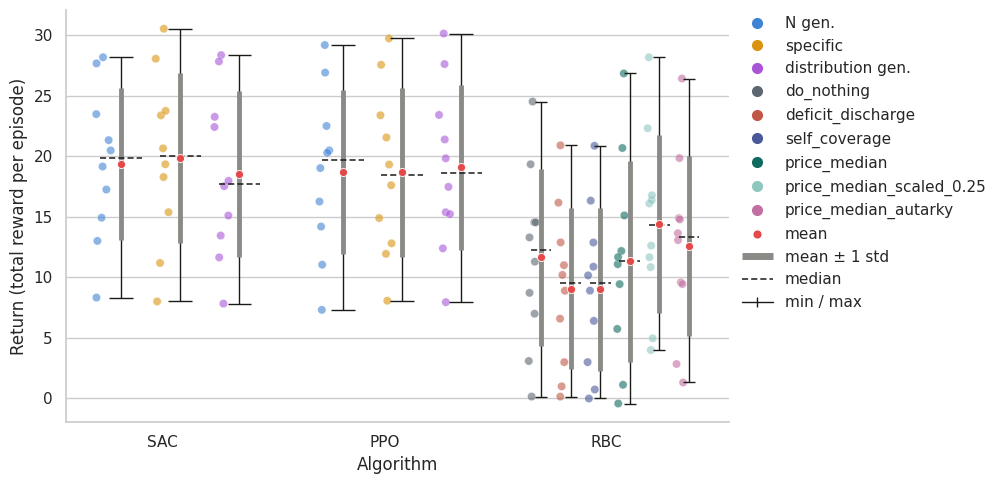

In [25]:
catplot_for_metric("total_reward")


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171314_gen_lin_bat_pv_all_sac/stat/catplot_cum_E_kWh_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171327_gen_lin_bat_pv_spec_sac/stat/catplot_cum_E_kWh_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac/stat/catplot_cum_E_kWh_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171650_gen_lin_bat_pv_all_ppo/stat/catplot_cum_E_kWh_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo/stat/catplot_cum_E_kWh_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo/stat/catplot_cum_E_kWh_al

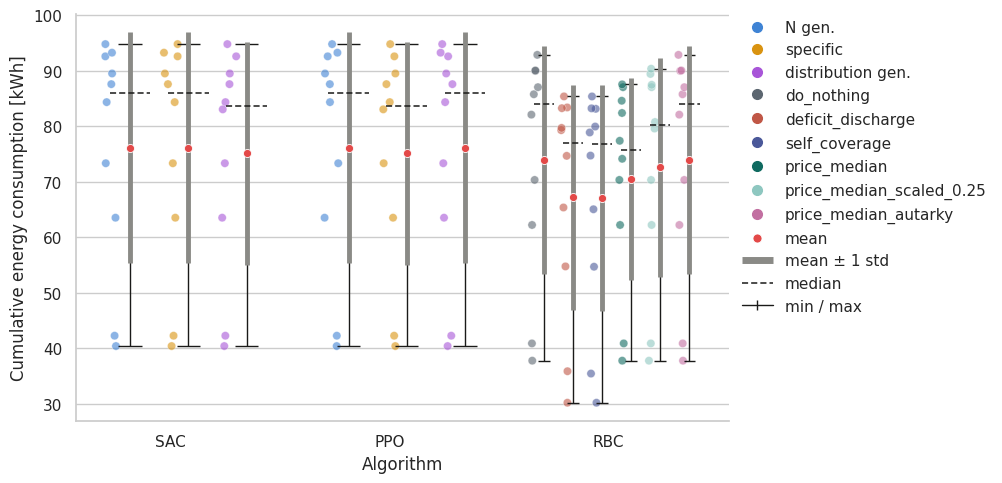

In [26]:
catplot_for_metric("cum_E_kWh")


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171314_gen_lin_bat_pv_all_sac/stat/catplot_cum_price_EUR_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171327_gen_lin_bat_pv_spec_sac/stat/catplot_cum_price_EUR_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac/stat/catplot_cum_price_EUR_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171650_gen_lin_bat_pv_all_ppo/stat/catplot_cum_price_EUR_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo/stat/catplot_cum_price_EUR_algo_variant_compare_eval_2_sac_vs_ppo_vs_rbc.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo/stat/

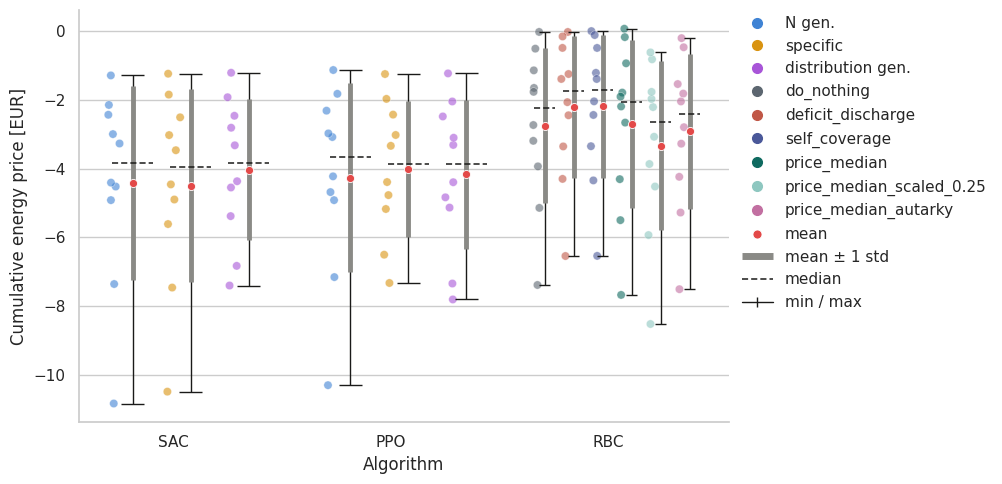

In [27]:
catplot_for_metric("cum_price_EUR")


## Per-strip statistics

One row per (algorithm, variant) — the exact values behind the stat glyphs, computed
over that strip's pooled eval episodes: episode `count`, `mean` (red dot), `std`
(grey-bar half-length), `median` (dashed line), `min` and `max` for every metric.

To export this table (CSV + LaTeX body) run the companion notebook
`snapshot_eval_stats_table_algo_compare.ipynb` — it shares this notebook's
main-input / discovery / load cells, so it picks up exactly the same data.


In [28]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
strip_stats = episodes.groupby(["algo", "variant"])[present_metrics].agg(
    ["count", "mean", "std", "median", "min", "max"]
).reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")
strip_stats


total_reward                                  \
                                     count       mean       std     median   
algo variant                                                                 
SAC  N gen.                             10  19.387978  6.287726  19.825442   
     specific                           10  19.864028  7.060475  20.002630   
     distribution gen.                  10  18.545265  6.847968  17.754441   
PPO  N gen.                             10  18.726408  6.773670  19.660465   
     specific                           10  18.693778  6.996497  18.469385   
     distribution gen.                  10  19.085956  6.834245  18.658974   
RBC  do_nothing                         10  11.649384  7.311559  12.294463   
     deficit_discharge                  10   9.075153  6.655681   9.544311   
     self_coverage                      10   9.011907  6.728483   9.528418   
     price_median                       10  11.344708  8.310288  11.379191   
     price_median_scaled_0.25           10  14.385014  7.351135  14.365283   
     price_median_autarky               10  12.585391  7.433624  13.361269   

                                                   cum_E_kWh             \
                                    min        max     count       mean   
algo variant                                                              
SAC  N gen.                    8.324213  28.194232        10  76.145481   
     specific                  8.005674  30.551187        10  76.145481   
     distribution gen.         7.825502  28.368572        10  75.125481   
PPO  N gen.                    7.308916  29.203538        10  76.145481   
     specific                  8.063914  29.749485        10  75.125481   
     distribution gen.         7.943807  30.152514        10  76.145481   
RBC  do_nothing                0.138051  24.532909        10  73.882293   
     deficit_discharge         0.136941  20.912159        10  67.176531   
     self_coverage            -0.018654  20.873621        10  67.054909   
     price_median             -0.433446  26.855704        10  70.415656   
     price_median_scaled_0.25  3.989260  28.190496        10  72.569793   
     price_median_autarky      1.304082  26.429367        10  73.882293   

                                                                           \
                                     std     median        min        max   
algo variant                                                                
SAC  N gen.                    20.753821  85.943948  40.403062  94.773174   
     specific                  20.753821  85.943948  40.403062  94.773174   
     distribution gen.         20.060103  83.675344  40.403062  94.773174   
PPO  N gen.                    20.753821  85.943948  40.403062  94.773174   
     specific                  20.060103  83.675344  40.403062  94.773174   
     distribution gen.         20.753821  85.943948  40.403062  94.773174   
RBC  do_nothing                20.548190  83.907558  37.773205  92.836042   
     deficit_discharge         20.314235  76.966945  30.203062  85.358074   
     self_coverage             20.360876  76.780628  30.203062  85.350978   
     price_median              18.192966  75.743948  37.773205  87.525872   
     price_median_scaled_0.25  19.641597  80.157558  37.773205  90.336042   
     price_median_autarky      20.548190  83.907558  37.773205  92.836042   

                              cum_price_EUR                                \
                                      count      mean       std    median   
algo variant                                                                
SAC  N gen.                              10 -4.416631  2.834989 -3.837804   
     specific                            10 -4.499630  2.807980 -3.960788   
     distribution gen.                   10 -4.024965  2.061843 -3.843349   
PPO  N gen.                              10 -4.260017  2.750192 -3.651902   
     specific                         

## Variance across eval seeds, per (algorithm, variant)

For each (algorithm, variant), the metric mean is first taken within each eval seed,
then aggregated (`mean` / `std` / `min` / `max`) across the seeds — a small `std`
means that source's eval performance is consistent across eval seeds rather than
driven by a lucky episode draw. With a single eval run per source (one seed) the
`std` column is `NaN` and `min` = `mean` = `max`; it becomes informative once
`_seed<N>` eval fan-outs exist.


In [29]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
seed_means = episodes.groupby(["algo", "variant", "seed"])[present_metrics].mean()
seed_means.groupby(["algo", "variant"]).agg(
    ["mean", "std", "min", "max"]
).reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")


total_reward                            \
                                      mean std        min        max   
algo variant                                                           
SAC  N gen.                      19.387978 NaN  19.387978  19.387978   
     specific                    19.864028 NaN  19.864028  19.864028   
     distribution gen.           18.545265 NaN  18.545265  18.545265   
PPO  N gen.                      18.726408 NaN  18.726408  18.726408   
     specific                    18.693778 NaN  18.693778  18.693778   
     distribution gen.           19.085956 NaN  19.085956  19.085956   
RBC  do_nothing                  11.649384 NaN  11.649384  11.649384   
     deficit_discharge            9.075153 NaN   9.075153   9.075153   
     self_coverage                9.011907 NaN   9.011907   9.011907   
     price_median                11.344708 NaN  11.344708  11.344708   
     price_median_scaled_0.25    14.385014 NaN  14.385014  14.385014   
     price_median_autarky        12.585391 NaN  12.585391  12.585391   

                               cum_E_kWh                            \
                                    mean std        min        max   
algo variant                                                         
SAC  N gen.                    76.145481 NaN  76.145481  76.145481   
     specific                  76.145481 NaN  76.145481  76.145481   
     distribution gen.         75.125481 NaN  75.125481  75.125481   
PPO  N gen.                    76.145481 NaN  76.145481  76.145481   
     specific                  75.125481 NaN  75.125481  75.125481   
     distribution gen.         76.145481 NaN  76.145481  76.145481   
RBC  do_nothing                73.882293 NaN  73.882293  73.882293   
     deficit_discharge         67.176531 NaN  67.176531  67.176531   
     self_coverage             67.054909 NaN  67.054909  67.054909   
     price_median              70.415656 NaN  70.415656  70.415656   
     price_median_scaled_0.25  72.569793 NaN  72.569793  72.569793   
     price_median_autarky      73.882293 NaN  73.882293  73.882293   

                              cum_price_EUR                          
                                       mean std       min       max  
algo variant                                                         
SAC  N gen.                       -4.416631 NaN -4.416631 -4.416631  
     specific                     -4.499630 NaN -4.499630 -4.499630  
     distribution gen.            -4.024965 NaN -4.024965 -4.024965  
PPO  N gen.                       -4.260017 NaN -4.260017 -4.260017  
     specific                     -4.016744 NaN -4.016744 -4.016744  
     distribution gen.            -4.167817 NaN -4.167817 -4.167817  
RBC  do_nothing                   -2.746635 NaN -2.746635 -2.746635  
     deficit_discharge            -2.200242 NaN -2.200242 -2.200242  
     self_coverage                -2.190498 NaN -2.190498 -2.190498  
     price_median                 -2.705491 NaN -2.705491 -2.705491  
     price_median_scaled_0.25     -3.329387 NaN -3.329387 -3.329387  
     price_median_autarky         -2.915859 NaN -2.915859 -2.915859